# Notebook Header & Import

In [1]:
# EEEM068: Industrial Waste Classification
# Evaluation Notebook (Jupyter version of test.py)

import os
import json
import argparse
import time

from sklearn import metrics
import yaml
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

from train import get_model, get_transforms, save_confusion_matrix, load_class_mapping

# Evaluation Function

In [2]:
@torch.no_grad()
def evaluate(model, loader, device, n_classes):
    """
    Evaluates the model and accurately measures inference latency.
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    # 1. WARMUP: Run one batch to initialize GPU kernels/memory allocation.
    # This prevents the first batch from skewing your average latency.
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    _ = model(dummy_input)

    # 2. START TIMER (with synchronization for GPU accuracy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start_time = time.time()

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    # 3. END TIMER (synchronize again to ensure all GPU tasks are done)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    total_time = time.time() - start_time
    
    # 4. CALCULATE LATENCY
    # ms per image = (total seconds * 1000) / total images
    latency = (total_time / len(loader.dataset)) * 1000 
    
    print("-" * 30)
    print(f"  INFERENCE PERFORMANCE")
    print("-" * 30)
    print(f"  Total Images: {len(loader.dataset)}")
    print(f"  Total Time:   {total_time:.2f}s")
    print(f"  Latency:      {latency:.2f} ms/image")
    print("-" * 30)

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )

# Metric Function


In [3]:
def compute_metrics(labels, preds, probs, n_classes, class_names=None):
    metrics_dict = {
        "accuracy": float(np.mean(labels == preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(labels, preds, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(labels, preds, average="macro", zero_division=0)),
    }

    # AUC
    try:
        one_hot = np.eye(n_classes)[labels]
        metrics_dict["auc"] = float(
            roc_auc_score(one_hot, probs, average="macro", multi_class="ovr")
        )
    except Exception as e:
        metrics_dict["auc"] = None
        print(f"[Warning] AUC could not be computed: {e}")

    # mAP
    try:
        one_hot = np.eye(n_classes)[labels]
        metrics_dict["mAP"] = float(
            average_precision_score(one_hot, probs, average="macro")
        )
    except Exception as e:
        metrics_dict["mAP"] = None
        print(f"[Warning] mAP could not be computed: {e}")

    # Per-class report
    metrics_dict["per_class_report"] = classification_report(
        labels, preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return metrics_dict

#  Save Metrics Function


In [4]:
def save_test_metrics(metrics, output_dir):
    path = os.path.join(output_dir, "test_metrics.json")
    with open(path, "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"[Metrics] Test results saved to {path}\n")

    print("="*40)
    print("  TEST RESULTS")
    print("="*40)
    for k, v in metrics.items():
        if k == "per_class_report":
            continue
        print(f"{k:<20} {v}")
    print("="*40)

# Visualizations

In [5]:
def plot_per_class_f1(metrics, class_names, output_dir):
    """
    Creates a horizontal bar chart of F1-scores for all 28 classes.
    """
    # Extract F1-scores from the per_class_report dictionary
    f1_scores = [metrics["per_class_report"][cls]["f1-score"] for cls in class_names]
    
    # Sort them so the chart is easier to read (highest performance at the top)
    sorted_data = sorted(zip(class_names, f1_scores), key=lambda x: x[1], reverse=True)
    sorted_classes, sorted_f1 = zip(*sorted_data)

    plt.figure(figsize=(12, 10))
    sns.set_style("whitegrid")
    
    # Create the plot
    ax = sns.barplot(x=list(sorted_f1), y=list(sorted_classes), hue=list(sorted_classes), palette="viridis", legend=False)
    
    # Add a vertical line for the Macro Average F1
    mean_f1 = metrics["f1_macro"]
    plt.axvline(x=mean_f1, color='red', linestyle='--', label=f'Macro Avg F1: {mean_f1:.2f}')
    
    plt.title("Per-Class F1-Score (Test Set)", fontsize=16)
    plt.xlabel("F1-Score", fontsize=12)
    plt.ylabel("Waste Category", fontsize=12)
    plt.xlim(0, 1.0) # F1 is always between 0 and 1
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    
    # Save the figure for your IEEE report
    plot_path = os.path.join(output_dir, "per_class_f1_bar.png")
    plt.savefig(plot_path, dpi=300)
    print(f"[Visuals] Per-class F1 plot saved to {plot_path}")
    plt.show()

In [6]:
def plot_misclassified(model, loader, device, class_names, n_images=5, output_dir=None):
    model.eval()
    errors = []

    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            probs = torch.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)
            
            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    # Store information about the mistake
                    errors.append({
                        "img": images[i], # Keep original tensor for plotting
                        "pred": class_names[preds[i]],
                        "label": class_names[labels[i]],
                        "conf": conf[i].item()
                    })

    # Sort by confidence: High confidence mistakes are the most "interesting"
    errors = sorted(errors, key=lambda x: x["conf"], reverse=True)[:n_images]

    # Plotting
    fig, axes = plt.subplots(1, n_images, figsize=(20, 5))
    if n_images == 1: axes = [axes]
    
    for i, error in enumerate(errors):
        # Un-normalize the image for display
        img = error["img"].permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {error['pred']}\nActual: {error['label']}\nConf: {error['conf']:.2f}", 
                          color='red', fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "top_mistakes.png"), dpi=300)
    plt.show()

# GradCAM Stub

In [7]:
def run_gradcam(model, loader, device, output_dir, n_samples=8):
    try:
        from pytorch_grad_cam import GradCAM
        from pytorch_grad_cam.utils.image import show_cam_on_image

        print("[GradCAM] TODO: implement full GradCAM visualisation here")

    except ImportError:
        print("[GradCAM] Install pytorch-grad-cam: pip install grad-cam")

# Main Evaluation Logic

In [8]:
from xml.parsers.expat import model


def run_evaluation(run_folder, enable_gradcam=False):
    # Load config
    config_path = os.path.join(run_folder, "config.yaml")
    with open(config_path) as f:
        config = yaml.safe_load(f)

    print(f"Evaluating run: {config['run']['name']}")
    print(f"Model: {config['run']['model']}")

    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Device] {device}")

    # Model
    model = get_model(config).to(device)
    ckpt_path = os.path.join(run_folder, "best_model.pth")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"[Model] Loaded checkpoint from {ckpt_path}")

    # Test loader
    test_tf = get_transforms(config, train=False)
    test_dataset = datasets.ImageFolder(
        root=os.path.join(config["dataset"]["data_root"], "test"),
        transform=test_tf
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["evaluation"]["batch_size"],
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # Class names
    mapping = load_class_mapping(config)
    class_names = [mapping["label_to_class"][str(i)]
                   for i in range(config["dataset"]["n_classes"])]

    # Evaluate
    preds, labels, probs = evaluate(model, test_loader, device, len(class_names))

    # Metrics
    metrics = compute_metrics(labels, preds, probs, len(class_names), class_names)
    save_test_metrics(metrics, run_folder)
    plot_per_class_f1(metrics, class_names, run_folder)
    print("Plotting top misclassifications...")
    plot_misclassified(model, test_loader, device, class_names, n_images=5, output_dir=run_folder)

    # Confusion matrix
    if config["output"]["save_confusion_matrix"]:
        save_confusion_matrix(labels, preds, class_names, run_folder)

    # GradCAM
    if enable_gradcam or config["output"].get("save_gradcam", False):
        run_gradcam(model, test_loader, device, run_folder)

    print(f"[Done] All test outputs saved to: {run_folder}")

# Example Usage


Evaluating run: smoke_test
Model: resnet50
[Device] cuda
[Model] Loading resnet50 (pretrained=False)
[Model] Params — total: 23,565,404 | trainable: 23,565,404
[Model] Loaded checkpoint from experiments/results/resnet50/smoke_test\best_model.pth
------------------------------
  INFERENCE PERFORMANCE
------------------------------
  Total Images: 1551
  Total Time:   15.59s
  Latency:      10.05 ms/image
------------------------------
[Metrics] Test results saved to experiments/results/resnet50/smoke_test\test_metrics.json

  TEST RESULTS
accuracy             0.27852998065764023
f1_macro             0.12749142705950414
f1_weighted          0.19515916357128255
precision_macro      0.13852419112243972
recall_macro         0.16024911616364027
auc                  0.8205990292425439
mAP                  0.20593512093143465
[Visuals] Per-class F1 plot saved to experiments/results/resnet50/smoke_test\per_class_f1_bar.png


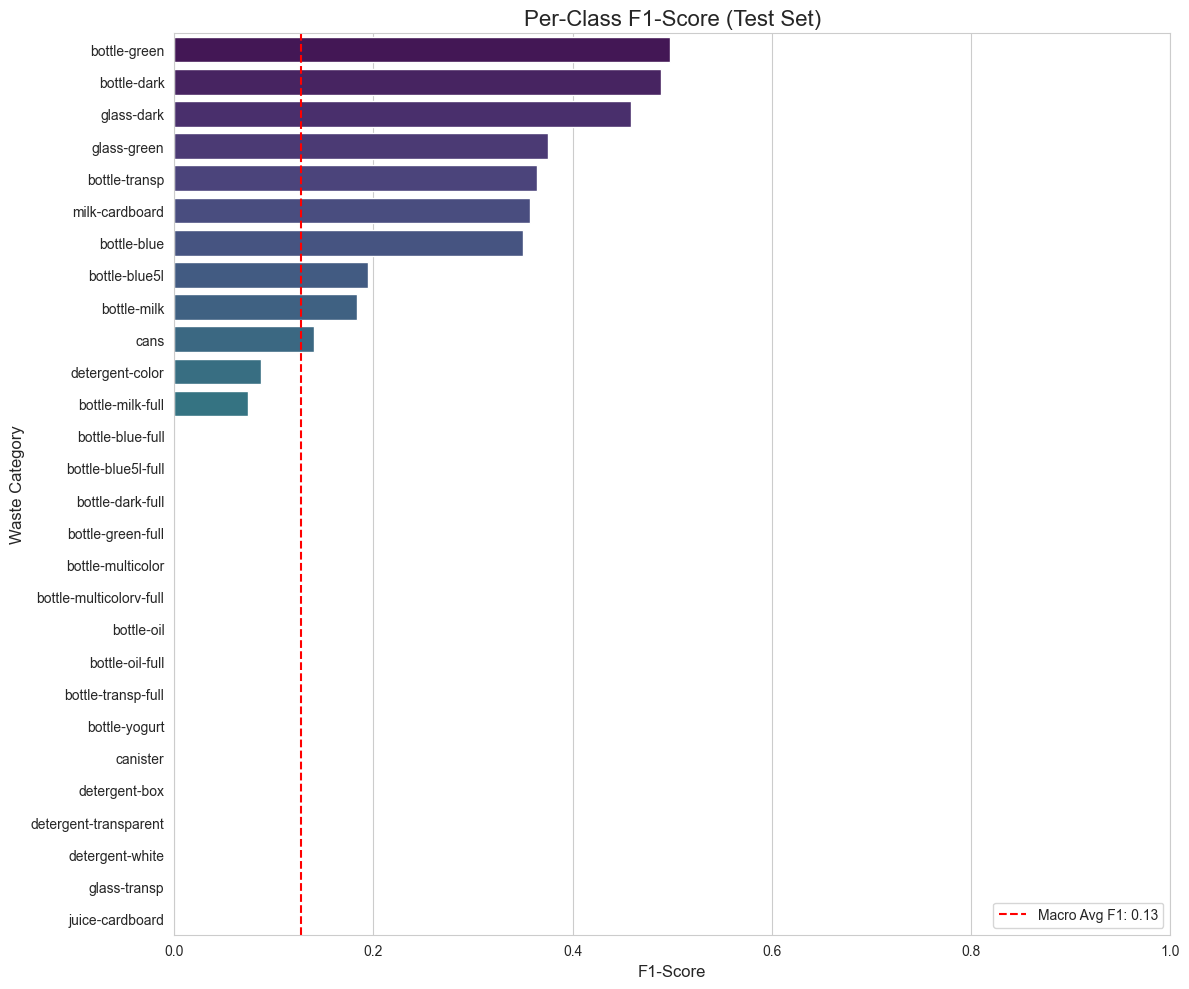

Plotting top misclassifications...


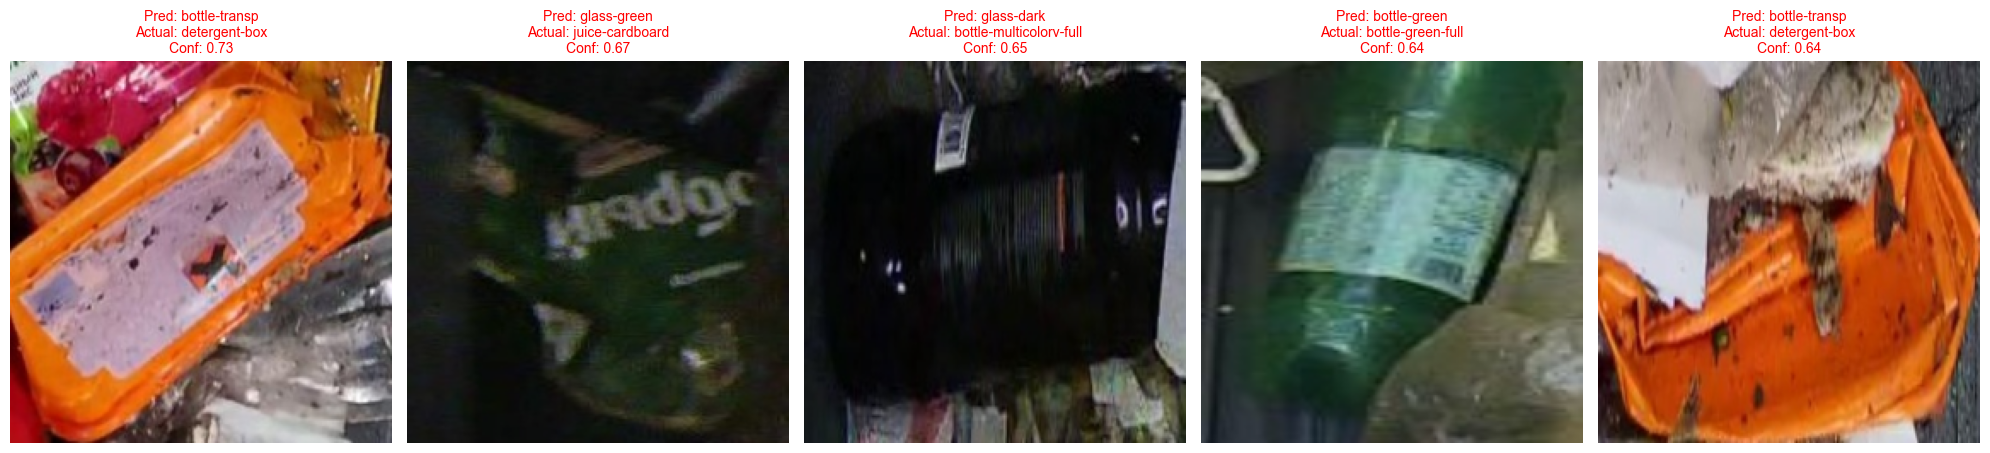

[Plot] Confusion matrix saved to experiments/results/resnet50/smoke_test\confusion_matrix.png
[Done] All test outputs saved to: experiments/results/resnet50/smoke_test


In [9]:
# Example: evaluate a run
run_evaluation("experiments/results/resnet50/smoke_test")